In [1]:
import pandas as pd

df_csv = pd.read_csv(
    '/Users/lgu/Desktop/stream-performance/performance-analysis/csv/stream-performance-csv/time.tsv',
    sep='\t',
    header=None,
    names=["input_size", "format", "query_type", "TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "EXECUTOR", "TIME"]
)

df_csv = df_csv[~df_csv["TIME"].isin(["-"])].copy()
df_csv = df_csv[~df_csv["TIME"].isin(["T"])].copy()
df_csv["TIME"] = pd.to_numeric(df_csv["TIME"])

cols = ["H", "K", "TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "NODES", "TIME"]


In [2]:
q_info = pd.read_csv('/Users/lgu/Desktop/q_info.tsv', sep='\t')

df_csv = df_csv.merge(
    q_info[["query_type", "TPs", "VARs", "VARs_ON_P", "NODES"]],
    on=["query_type", "TPs", "VARs", "VARs_ON_P"],
    how="left"
)

df_csv["H"] = 1
df_csv["K"] = 10

csv_corr = df_csv[cols].apply(pd.to_numeric, errors="coerce").corr()


In [3]:
df_csv

,input_size,format,query_type,TPs,VARs,VARs_ON_P,SOL_P,BINDINGS,EXECUTOR,TIME,NODES,H,K
0,100000,csv,H_1,1,1,0,1,1010,stream,1017,1,1,10
1,100000,csv,H_1,1,1,0,1,1010,stream,859,1,1,10
2,100000,csv,H_1,1,1,0,1,1010,stream,900,1,1,10
3,100000,csv,H_1,1,2,0,2,100001,stream,1519,2,1,10
4,100000,csv,H_1,1,2,1,2,2026,stream,898,2,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,100000,csv,H_1,10,9,1,256,1010,stream,192466,256,1,10
368,100000,csv,H_1,10,9,0,256,1010,stream,122764,256,1,10
369,100000,csv,H_1,10,9,1,256,1010,stream,185277,256,1,10
370,100000,csv,H_1,10,10,0,512,1010,stream,261447,512,1,10


In [4]:
csv_corr

,H,K,TPs,VARs,VARs_ON_P,SOL_P,BINDINGS,NODES,TIME
H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
K,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TPs,NaN,NaN,1.000000,0.407829,-0.035301,0.289166,-0.236435,0.289166,0.213580
VARs,NaN,NaN,0.407829,1.000000,0.143730,0.735459,0.227173,0.735459,0.607574
VARs_ON_P,NaN,NaN,-0.035301,0.143730,1.000000,0.101253,0.251866,0.101253,0.167148
SOL_P,NaN,NaN,0.289166,0.735459,0.101253,1.000000,0.324595,1.000000,0.932354
BINDINGS,NaN,NaN,-0.236435,0.227173,0.251866,0.324595,1.000000,0.324595,0.419972
NODES,NaN,NaN,0.289166,0.735459,0.101253,1.000000,0.324595,1.000000,0.932354
TIME,NaN,NaN,0.213580,0.607574,0.167148,0.932354,0.419972,0.932354,1.000000


In [5]:
time_file = '/Users/lgu/Desktop/ISWC2026-test/stream-performance-json2/time.tsv' 

df_json = pd.read_csv(
    time_file,
    sep='\t',
    header=None,
    names=["input_size", "format", "query_type", "TPs", "VARs", "VARs_ON_P", "SOL_P", "NODES", "BINDINGS", "EXECUTOR", "TIME"]
)


df_json = df_json[~df_json["TIME"].isin(["-"])].copy()

df_json = df_json[~df_json["TIME"].isin(["T"])].copy()
df_json["TIME"] = pd.to_numeric(df_json["TIME"])

df_json[["H", "K"]] = df_json["query_type"].str.extract(r"H=(\d+)_K=(\d+)").astype(int)

json_corr = df_json[cols].apply(pd.to_numeric, errors="coerce").corr()

In [6]:
df_xml = pd.read_csv(
    '/Users/lgu/Desktop/ISWC2026-test/stream-performance-xml/time.tsv',
    sep='\t',
    header=None,
    names=["input_size", "format", "query_type", "TPs", "VARs", "VARs_ON_P", "SOL_P", "NODES", "BINDINGS", "EXECUTOR", "TIME"]
)

df_xml = df_xml[~df_xml["TIME"].isin(["-"])].copy()


df_xml = df_xml[~df_xml["TIME"].isin(["T"])].copy()
df_xml["TIME"] = pd.to_numeric(df_xml["TIME"])

df_xml[["H", "K"]] = df_xml["query_type"].str.extract(r"H=(\d+)_K=(\d+)").astype(int)


xml_corr = df_xml[cols].apply(pd.to_numeric, errors="coerce").corr()


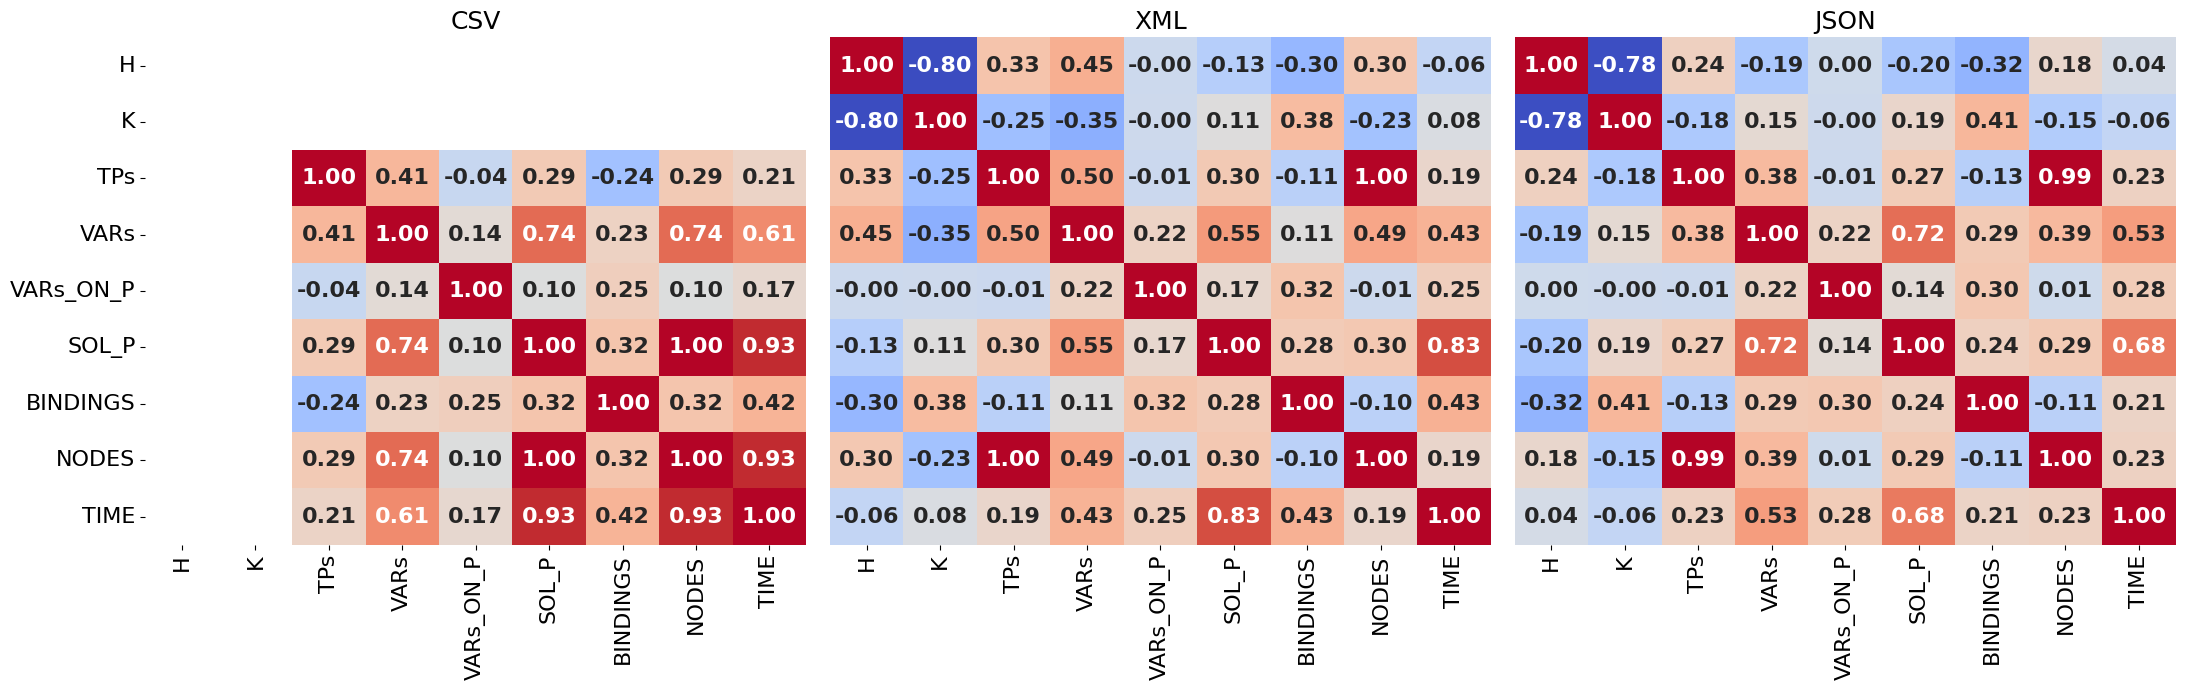

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Shared value range for a single color scale
vmin = min(csv_corr.min().min(), xml_corr.min().min(), json_corr.min().min())
vmax = max(csv_corr.max().max(), xml_corr.max().max(), json_corr.max().max())

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

font_size = 16
annot_kws = {"size": font_size, "fontweight": "bold"}

for i, (ax, corr, title) in enumerate(zip(axes, [csv_corr, xml_corr, json_corr], ["CSV", "XML", "JSON"])):
    sns.heatmap(
        corr, ax=ax, cmap="coolwarm",
        annot=True, fmt='.2f',
        annot_kws=annot_kws,
        vmin=vmin, vmax=vmax,
        cbar=False,
        xticklabels=corr.columns,
        yticklabels=corr.index if i == 0 else False,
    )
    ax.set_title(title, fontsize=font_size + 2)
    ax.tick_params(axis='both', labelsize=font_size)

plt.tight_layout()
plt.show()
